In [ ]:
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from shapely import wkt
from shapely.ops import transform
from pyproj import Transformer

engine = create_engine(os.environ["PG_CONN"])

# ----------------------------
# LOAD + FILTER
# ----------------------------
df = pd.read_sql("SELECT * FROM src.evaluation", engine)
df["tags"] = df["tags"].apply(lambda x: x if isinstance(x, dict) else json.loads(x))

df = df[
    (df["post"] == "perfect") &
    (df["tags"].apply(lambda t: "SHIFTED" in (t.get("original_errors") or [])))
]

# ----------------------------
# LOAD GEOMS
# ----------------------------
geom = pd.read_sql("""
SELECT
    b.id AS building_id,
    ST_AsText(b.geom) AS original_geom,
    ST_AsText(r.geom) AS post_geom
FROM src.buildings b
JOIN src.detected_house_regularized r
    ON r.building_id = b.id
""", engine)

df = df.merge(geom, on="building_id")

# ----------------------------
# PROJECT TO METERS (IMPORTANT)
# ----------------------------
proj = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True).transform

def orientation(poly):
    try:
        rect = poly.minimum_rotated_rectangle
        coords = list(rect.exterior.coords)
        dx = coords[1][0] - coords[0][0]
        dy = coords[1][1] - coords[0][1]
        return np.degrees(np.arctan2(dy, dx))
    except:
        return np.nan

dxs, dys, dists, angles, rot_diffs = [], [], [], [], []

for _, row in df.iterrows():
    try:
        g1 = transform(proj, wkt.loads(row.original_geom))
        g2 = transform(proj, wkt.loads(row.post_geom))

        c1, c2 = g1.centroid, g2.centroid

        dx = c2.x - c1.x
        dy = c2.y - c1.y

        dxs.append(dx)
        dys.append(dy)
        dists.append(np.hypot(dx, dy))

        # direction of shift
        angles.append(np.degrees(np.arctan2(dy, dx)))

        # orientation difference
        o1 = orientation(g1)
        o2 = orientation(g2)
        rot_diffs.append(o2 - o1)

    except:
        dxs.append(np.nan)
        dys.append(np.nan)
        dists.append(np.nan)
        angles.append(np.nan)
        rot_diffs.append(np.nan)

df["dx"], df["dy"], df["dist"] = dxs, dys, dists
df["angle"] = angles
df["rot_diff"] = rot_diffs

df = df.dropna()

# ----------------------------
# RESULTS
# ----------------------------
print("\n=== SHIFT (meters) ===")
print(df[["dx","dy","dist"]].describe())

print("\n=== ROTATION DIFF (deg) ===")
print(df["rot_diff"].describe())

# ----------------------------
# PLOTS
# ----------------------------

# shift vectors
plt.figure()
plt.scatter(df["dx"], df["dy"])
plt.axhline(0)
plt.axvline(0)
plt.xlabel("dx (m)")
plt.ylabel("dy (m)")
plt.title("Shift vectors")
plt.show()

# direction distribution
plt.figure()
plt.hist(df["angle"], bins=30)
plt.title("Shift direction (deg)")
plt.show()

# rotation difference
plt.figure()
plt.hist(df["rot_diff"], bins=30)
plt.title("Rotation difference (deg)")
plt.show()

Loaded: 399

=== VERTICES ===
       orig_vertices  post_vertices
count     399.000000     399.000000
mean        5.413534      14.796992
std         0.972960      25.551925
min         5.000000       5.000000
25%         5.000000       5.000000
50%         5.000000       7.000000
75%         5.000000       9.000000
max        11.000000     179.000000
→ more vertices (more complex): 0.544
→ fewer vertices (simplified): 0.043

=== COMPLEXITY (perimeter/area) ===
       orig_complex  post_complex
count    399.000000    399.000000
mean       0.494507      0.487646
std        0.210028      0.271576
min        0.184956      0.178476
25%        0.339881      0.330864
50%        0.436162      0.408152
75%        0.600481      0.543738
max        1.356007      2.705112
→ more complex: 0.561
→ simpler    : 0.439

=== RECTANGULARITY (0–1, higher = cleaner) ===
        orig_rect   post_rect
count  399.000000  399.000000
mean     0.971283    0.913986
std      0.064451    0.101678
min      0.568465

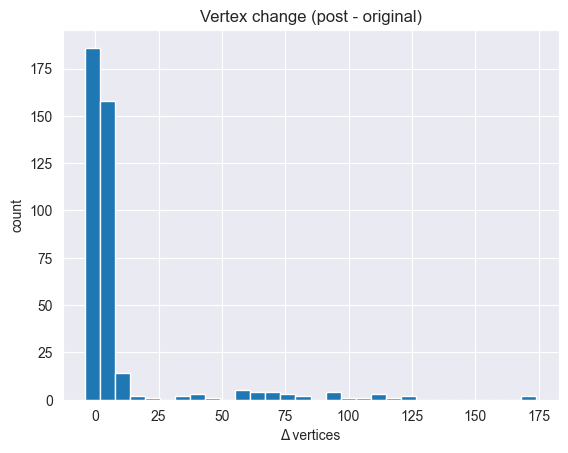

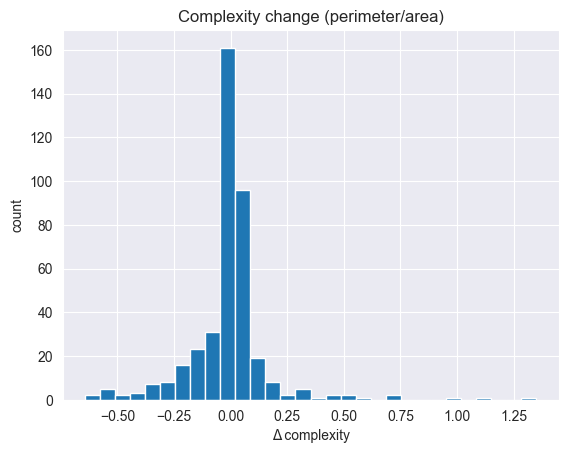

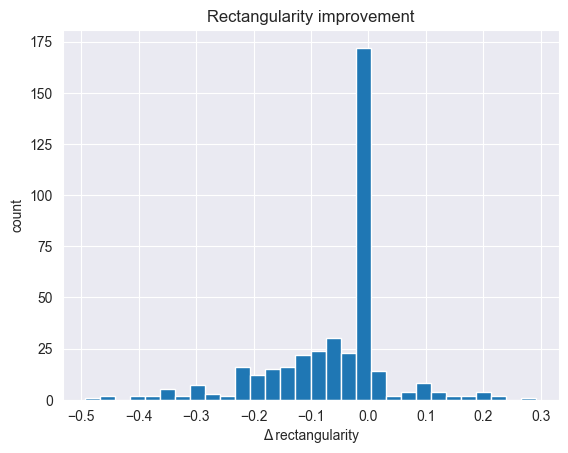

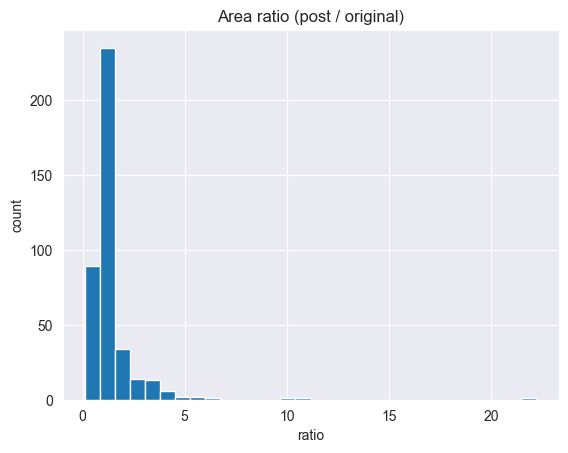

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from shapely import wkt
from shapely.ops import transform
from pyproj import Transformer

# ----------------------------
# DB
# ----------------------------
engine = create_engine(os.environ["PG_CONN"])

# ----------------------------
# LOAD CORRECT DATA
# ----------------------------
df = pd.read_sql("""
SELECT
    b.id AS building_id,
    ST_AsText(b.geom) AS original_geom,
    ST_AsText(r.geom) AS post_geom
FROM src.buildings b
JOIN src.detected_house_regularized r
    ON r.building_id = b.id
WHERE r.geom IS NOT NULL
""", engine)

print("Loaded:", len(df))

# ----------------------------
# PROJECT TO METERS (CRITICAL)
# ----------------------------
proj = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True).transform

# ----------------------------
# METRIC FUNCTIONS
# ----------------------------
def n_vertices(g):
    if g.geom_type == "Polygon":
        return len(g.exterior.coords)
    elif g.geom_type == "MultiPolygon":
        return sum(len(p.exterior.coords) for p in g.geoms)
    return np.nan

def perimeter(g):
    return g.length

def area(g):
    return g.area

def complexity(g):
    # normalized complexity: perimeter relative to area
    return g.length / (g.area + 1e-6)

def rectangularity(g):
    try:
        return g.area / g.minimum_rotated_rectangle.area
    except:
        return np.nan

# ----------------------------
# COMPUTE METRICS
# ----------------------------
rows = []

for _, row in df.iterrows():
    try:
        g1 = transform(proj, wkt.loads(row.original_geom))
        g2 = transform(proj, wkt.loads(row.post_geom))

        rows.append({
            # vertices
            "orig_vertices": n_vertices(g1),
            "post_vertices": n_vertices(g2),

            # geometry
            "orig_area": area(g1),
            "post_area": area(g2),

            "orig_perimeter": perimeter(g1),
            "post_perimeter": perimeter(g2),

            # complexity
            "orig_complex": complexity(g1),
            "post_complex": complexity(g2),

            # shape regularity
            "orig_rect": rectangularity(g1),
            "post_rect": rectangularity(g2)
        })

    except:
        continue

df = pd.DataFrame(rows)

# ----------------------------
# DERIVED
# ----------------------------
df["vertex_diff"] = df["post_vertices"] - df["orig_vertices"]
df["complex_diff"] = df["post_complex"] - df["orig_complex"]
df["rect_diff"] = df["post_rect"] - df["orig_rect"]
df["area_ratio"] = df["post_area"] / (df["orig_area"] + 1e-6)

# ----------------------------
# RESULTS
# ----------------------------
print("\n=== VERTICES ===")
print(df[["orig_vertices","post_vertices"]].describe())
print("→ more vertices (more complex):", (df["vertex_diff"] > 0).mean().round(3))
print("→ fewer vertices (simplified):", (df["vertex_diff"] < 0).mean().round(3))

print("\n=== COMPLEXITY (perimeter/area) ===")
print(df[["orig_complex","post_complex"]].describe())
print("→ more complex:", (df["complex_diff"] > 0).mean().round(3))
print("→ simpler    :", (df["complex_diff"] < 0).mean().round(3))

print("\n=== RECTANGULARITY (0–1, higher = cleaner) ===")
print(df[["orig_rect","post_rect"]].describe())
print("→ more rectangular:", (df["rect_diff"] > 0).mean().round(3))

print("\n=== AREA CHANGE ===")
print(df["area_ratio"].describe())
print("→ larger buildings:", (df["area_ratio"] > 1.05).mean().round(3))
print("→ smaller buildings:", (df["area_ratio"] < 0.95).mean().round(3))

# ----------------------------
# PLOTS (THESIS READY)
# ----------------------------

# vertex change
plt.figure()
plt.hist(df["vertex_diff"], bins=30)
plt.title("Vertex change (post - original)")
plt.xlabel("Δ vertices")
plt.ylabel("count")
plt.show()

# complexity change
plt.figure()
plt.hist(df["complex_diff"], bins=30)
plt.title("Complexity change (perimeter/area)")
plt.xlabel("Δ complexity")
plt.ylabel("count")
plt.show()

# rectangularity
plt.figure()
plt.hist(df["rect_diff"], bins=30)
plt.title("Rectangularity improvement")
plt.xlabel("Δ rectangularity")
plt.ylabel("count")
plt.show()

# area ratio
plt.figure()
plt.hist(df["area_ratio"], bins=30)
plt.title("Area ratio (post / original)")
plt.xlabel("ratio")
plt.ylabel("count")
plt.show()

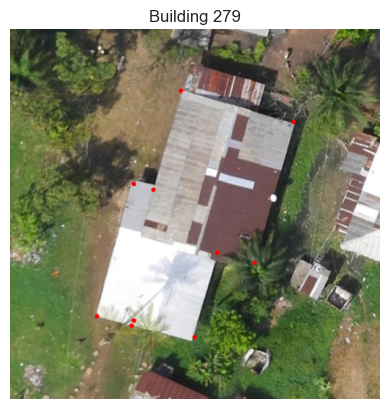

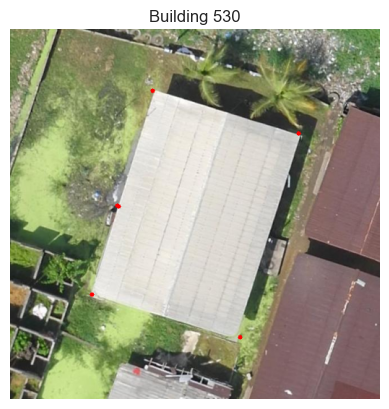

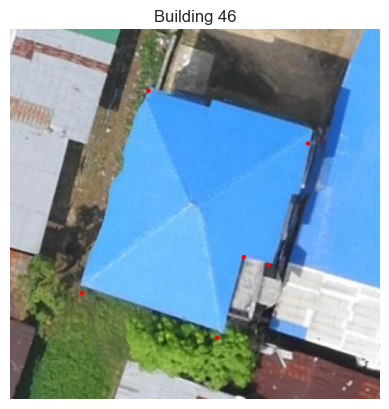

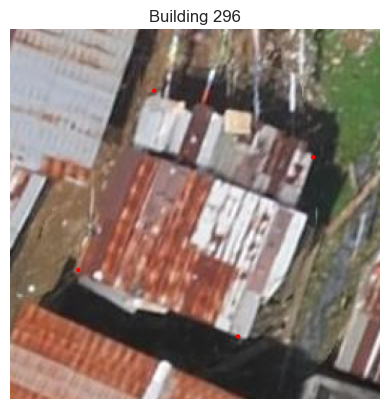

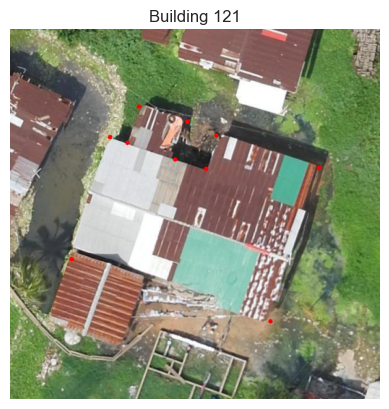

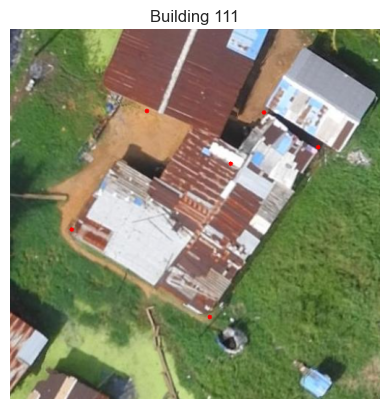

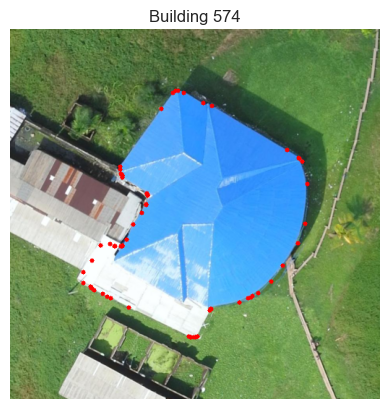

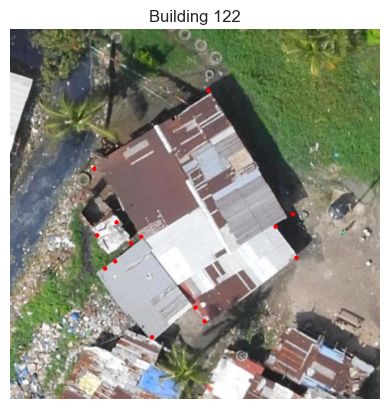

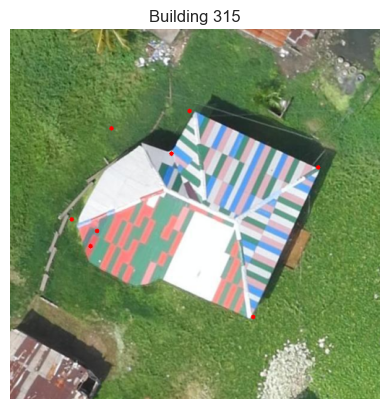

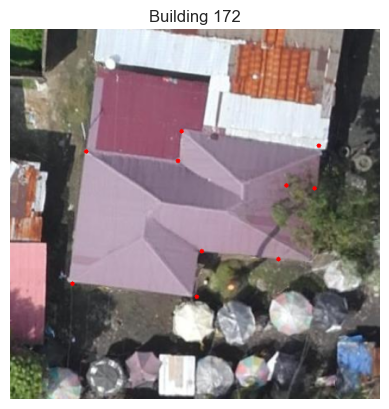

In [4]:
import os
import random
import cv2
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from shapely import wkt
from shapely.ops import transform as shp_transform
from pyproj import Transformer

from src.patches.extractor import extract_patch

# ----------------------------
# DB
# ----------------------------
engine = create_engine(os.environ["PG_CONN"])

# ----------------------------
# LOAD DATA
# ----------------------------
df = pd.read_sql("""
SELECT
    b.id AS building_id,
    b.tiff_path,
    ST_AsText(b.geom) AS original_geom,
    ST_AsText(r.geom) AS post_geom
FROM src.buildings b
JOIN src.detected_house_regularized r
    ON r.building_id = b.id
WHERE r.geom IS NOT NULL
""", engine)

# sample 10 random buildings
df = df.sample(10, random_state=42)

# ----------------------------
# HELPERS
# ----------------------------
def to_geom(w):
    try:
        return wkt.loads(w)
    except:
        return None

def draw_vertices(img, geom, color):
    if geom is None:
        return img

    try:
        coords = list(geom.exterior.coords)
        for x, y in coords:
            cv2.circle(img, (int(x), int(y)), 3, color, -1)
    except:
        pass
    return img

# ----------------------------
# PROCESS + PLOT
# ----------------------------
for _, row in df.iterrows():

    original = to_geom(row.original_geom)
    post = to_geom(row.post_geom)

    if original is None or post is None:
        continue

    # ----------------------------
    # extract image patch
    # ----------------------------
    img, _, win = extract_patch(
        post,  # center on improved
        "EPSG:4326",
        row.tiff_path,
        context=1.5
    )

    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # ----------------------------
    # transform setup
    # ----------------------------
    with rasterio.open(row.tiff_path) as src:
        raster_crs = src.crs
        affine = src.window_transform(win)

    inv = ~affine
    h, w = img.shape[:2]
    sx = w / win.width
    sy = h / win.height

    to_raster = Transformer.from_crs(
        "EPSG:4326",
        raster_crs,
        always_xy=True
    ).transform

    def world_to_pixel(geom):
        g = shp_transform(to_raster, geom)
        g = shp_transform(lambda x, y: inv * (x, y), g)
        g = shp_transform(lambda x, y: (x * sx, y * sy), g)
        return g

    original_px = world_to_pixel(original)
    post_px = world_to_pixel(post)

    # ----------------------------
    # draw vertices
    # ----------------------------
    img_vis = img.copy()

    img_vis = draw_vertices(img_vis, original_px, (0, 255, 255))  # yellow = original
    img_vis = draw_vertices(img_vis, post_px, (0, 0, 255))        # red = post

    # ----------------------------
    # show
    # ----------------------------
    plt.figure()
    plt.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
    plt.title(f"Building {row.building_id}")
    plt.axis("off")
    plt.show()